In [1]:
# Imports
import os
from pathlib import Path
markers = (".git", "Program")
current_dir = Path.cwd()
project_root = next((path for path in (current_dir, *current_dir.parents) if any((path / marker).exists() for marker in markers)), current_dir)
os.chdir(project_root)

import concurrent.futures
import datetime as dt
from functools import partial
from fundamentals import *
from helper_functions import modify_current_date, get_df, get_excel_filename, get_infix, get_volume5m_data, generate_end_dates, merge_stocks, stock_market
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import multiprocessing
import numpy as np
import pandas as pd
from pandas import ExcelWriter as EW
from plot import *
import random
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize
from scipy.stats import false_discovery_control, kendalltau, linregress, pearsonr, spearmanr, ttest_ind, wilcoxon
from stock_screener import check_conds_tech, check_conds_fund, EM_rating, get_stock_info, stoploss_target
from technicals import *
from tqdm import tqdm

# Start of the program
start = dt.datetime.now()

# Index
index_name = "^GSPC"
index_dict = {"^HSI": "HKEX", "^GSPC": "S&P 500", "^IXIC": "NASDAQ Composite"}

# Modify the current date
current_date = modify_current_date(start, index_name)

In [2]:
# Read and process the Fama-French 5 Factors data
ff5_data = pd.read_csv("Program/F-F_Research_Data_5_Factors_2x3_daily.csv", skiprows=3, index_col=0)
ff5_data = ff5_data.drop(ff5_data.index[-1])

# Convert index to datetime for time series analysis
ff5_data.index = pd.to_datetime(ff5_data.index, format="%Y%m%d")

# Display the data
ff5_data

,Mkt-RF,SMB,HML,RMW,CMA,RF
1963-07-01,-0.67,0.00,-0.34,-0.01,0.16,0.01
1963-07-02,0.79,-0.26,0.26,-0.07,-0.20,0.01
1963-07-03,0.63,-0.17,-0.09,0.18,-0.34,0.01
1963-07-05,0.40,0.08,-0.27,0.09,-0.34,0.01
1963-07-08,-0.63,0.04,-0.18,-0.29,0.14,0.01
...,...,...,...,...,...,...
2025-12-24,0.29,0.07,0.01,-0.05,0.23,0.02
2025-12-26,-0.06,-0.22,0.09,0.57,0.24,0.02
2025-12-29,-0.41,-0.17,0.07,0.32,0.02,0.02
2025-12-30,-0.20,-0.49,0.28,0.36,0.13,0.02


In [3]:
# Read and process the momentum factor data
ffwml_data = pd.read_csv("Program/F-F_Momentum_Factor_daily.csv", skiprows=13, index_col=0)
ffwml_data = ffwml_data.drop(ffwml_data.index[-1])

# Convert index to datetime for time series analysis
ffwml_data.index = pd.to_datetime(ffwml_data.index, format="%Y%m%d")

# Rename the column from Mom to WML
ffwml_data = ffwml_data.rename(columns={"Mom": "WML"})

# Display the data
ffwml_data

,WML
1926-11-03,0.54
1926-11-04,-0.51
1926-11-05,1.17
1926-11-06,-0.03
1926-11-08,-0.02
...,...
2025-12-24,-0.22
2025-12-26,-0.20
2025-12-29,-0.16
2025-12-30,-0.29


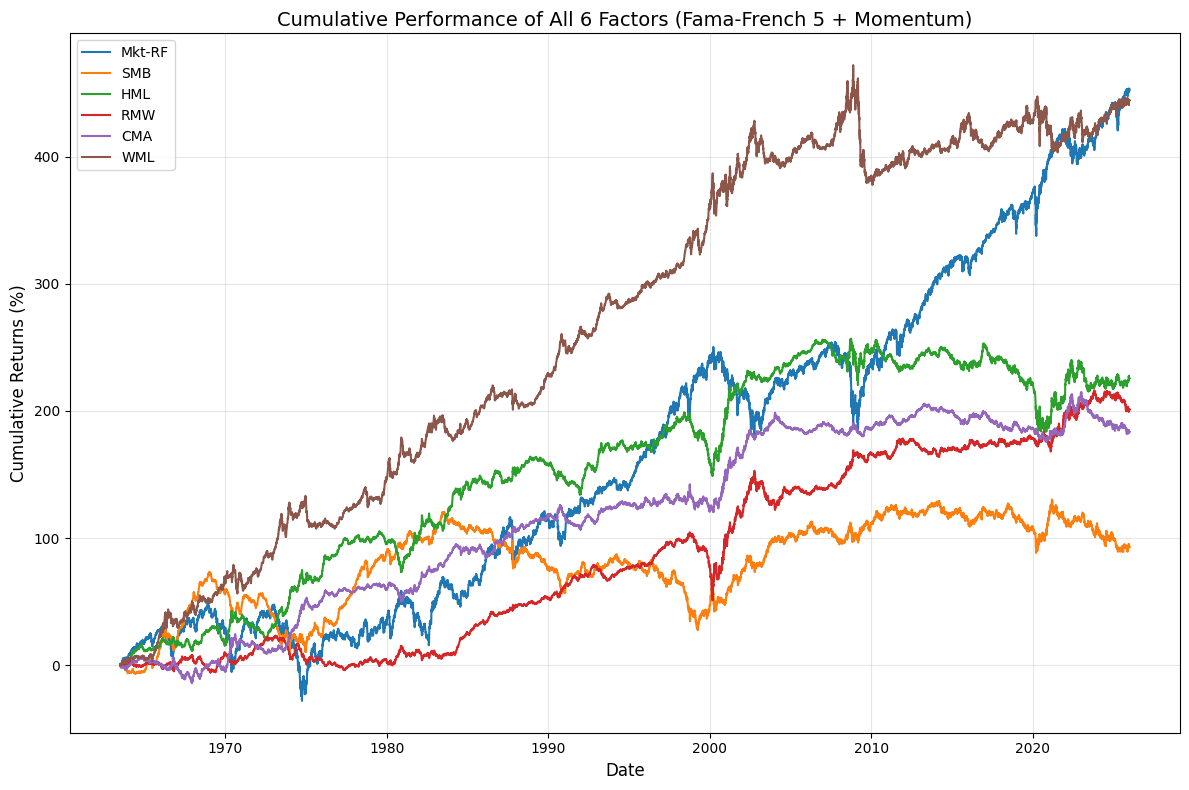

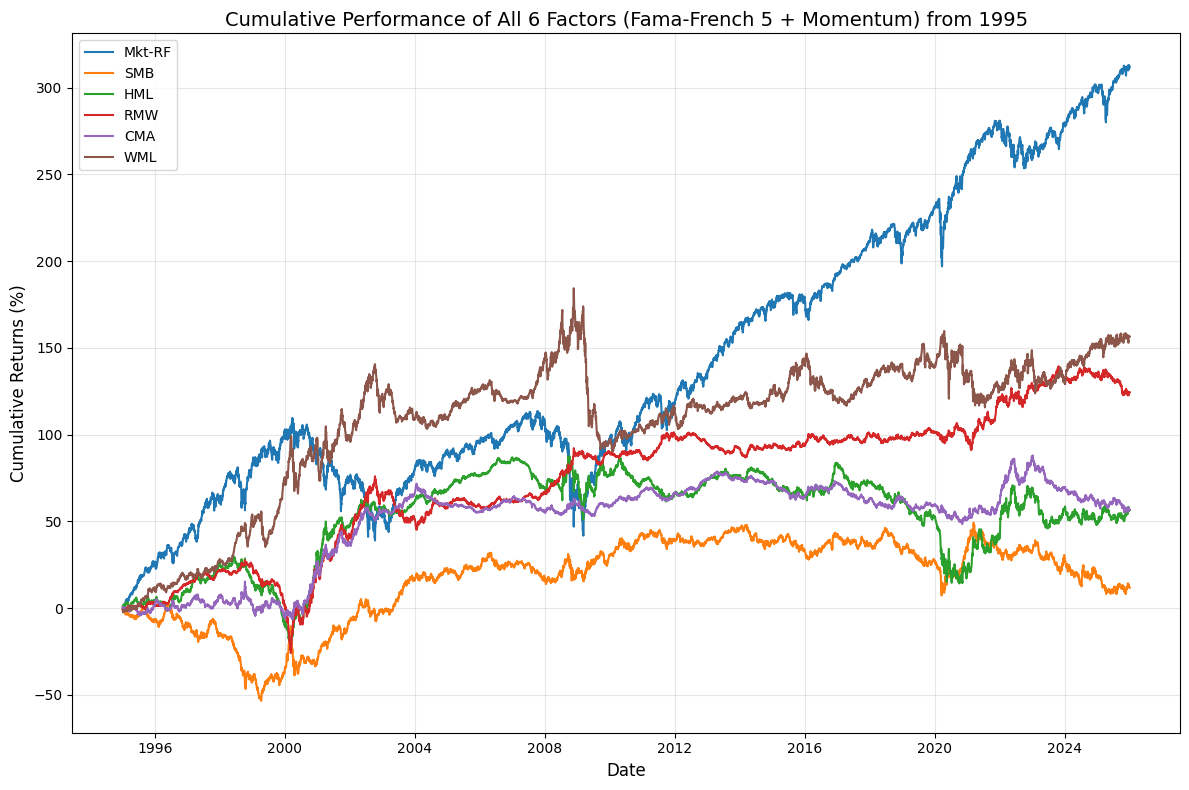

In [4]:
# Plot the performance of all 6 factors (5 Fama-French + Momentum)
plt.figure(figsize=(12, 8))

# Plot the 5 Fama-French factors
for column in ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]:
    plt.plot(ff5_data.index, ff5_data[column].cumsum(), label=column, linewidth=1.5)

# Plot the momentum factor (align dates with ff5_data)
wml_aligned = ffwml_data.reindex(ff5_data.index)
plt.plot(ff5_data.index, wml_aligned["WML"].cumsum(), label="WML", linewidth=1.5)

plt.title("Cumulative Performance of All 6 Factors (Fama-French 5 + Momentum)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Cumulative Returns (%)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Filter data to beyond 1995-01-01
start_date = "1995-01-01"
ff5_filtered = ff5_data[ff5_data.index >= start_date]
wml_filtered = wml_aligned[wml_aligned.index >= start_date]

plt.figure(figsize=(12, 8))

# Plot the 5 Fama-French factors with filtered data
for column in ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]:
    plt.plot(ff5_filtered.index, ff5_filtered[column].cumsum(), label=column, linewidth=1.5)

# Plot the momentum factor with filtered data
plt.plot(wml_filtered.index, wml_filtered["WML"].cumsum(), label="WML", linewidth=1.5)

plt.title("Cumulative Performance of All 6 Factors (Fama-French 5 + Momentum) from 1995", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Cumulative Returns (%)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Result/Figure/factor_performance_since_1995.png", dpi=300)
plt.show()

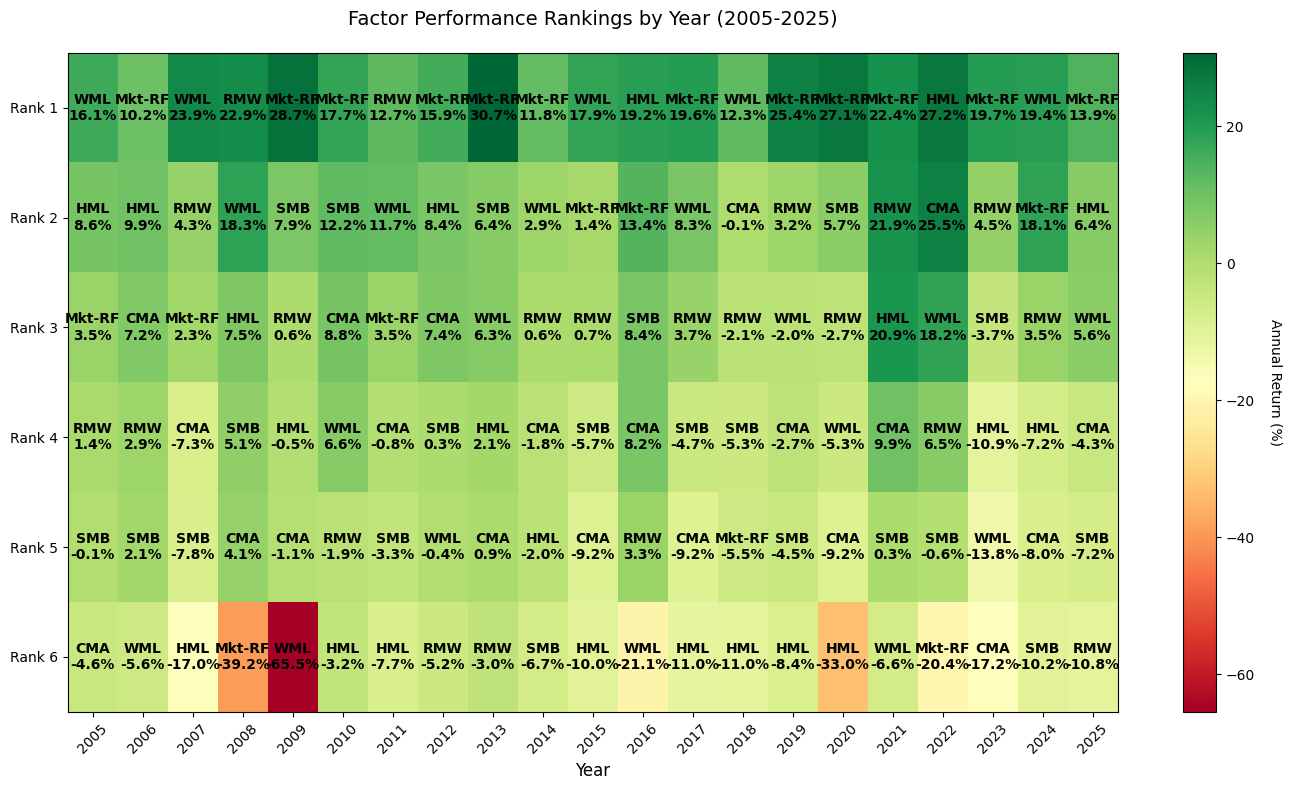

In [5]:
# Filter data (2005-2025)
start_date = pd.Timestamp("2005-01-01")
end_date = pd.Timestamp("2025-12-31")
ff5_past = ff5_data[(ff5_data.index >= start_date) & (ff5_data.index <= end_date)]
wml_past = wml_aligned[(wml_aligned.index >= start_date) & (wml_aligned.index <= end_date)]

# Calculate yearly returns
yearly_returns_past = ff5_past.groupby(ff5_past.index.year)[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].sum()
yearly_returns_past["WML"] = wml_past.groupby(wml_past.index.year)["WML"].sum()
# Create ranking data
years_past = yearly_returns_past.index
n_factors = len(yearly_returns_past.columns)

# Pre-allocate arrays for better performance
rank_values = np.zeros((n_factors, len(years_past)))
factor_labels = []

for i, year in enumerate(years_past):
    year_data = yearly_returns_past.loc[year].sort_values(ascending=False)
    rank_values[:, i] = year_data.values
    factor_labels.append([f"{factor}\n{val:.1f}%" for factor, val in zip(year_data.index, year_data.values)])

# Create matrices directly without intermediate DataFrames
rank_matrix_past = pd.DataFrame(rank_values, index=[f"Rank {i+1}" for i in range(n_factors)], columns=years_past)

# Create optimized heatmap
fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(rank_values, cmap="RdYlGn", aspect="auto")

# Set labels efficiently
ax.set_xticks(range(len(years_past)))
ax.set_xticklabels(years_past, rotation=45)
ax.set_yticks(range(n_factors))
ax.set_yticklabels([f"Rank {i+1}" for i in range(n_factors)])

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Annual Return (%)", rotation=270, labelpad=20)

# Add text annotations efficiently
for i in range(n_factors):
    for j in range(len(years_past)):
        ax.text(j, i, factor_labels[j][i], 
               ha="center", va="center", color="black", 
               fontsize=10, fontweight='bold')

ax.set_title("Factor Performance Rankings by Year (2005-2025)", fontsize=14, pad=20)
ax.set_xlabel("Year", fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
def ff6_decompose(df, ff5_data, ffwml_data):
    """
    Decomposes the stock factor into Fama-French 5 factors and WML with optimized performance.

    Parameters:
    df (DataFrame): DataFrame containing stock prices with "Close" column.
    ff5_data (DataFrame): Fama-French 5 factors data.
    ffwml_data (DataFrame): Momentum factor data.
    
    Returns:
    dict: Dictionary containing regression results and additional metrics.
    """
    
    # Calculate daily returns for stock
    stock_returns = df["Close"].pct_change().dropna() * 100
    
    # Get date range
    start_date, end_date = stock_returns.index[0], stock_returns.index[-1]

    # Filter factor data using boolean indexing
    date_mask_ff5 = (ff5_data.index >= start_date) & (ff5_data.index <= end_date)
    date_mask_wml = (ffwml_data.index >= start_date) & (ffwml_data.index <= end_date)
    
    ff5_stock = ff5_data.loc[date_mask_ff5]
    ffwml_stock = ffwml_data.loc[date_mask_wml]
    
    # Combine factors
    factors_stock = ff5_stock[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].join(
        ffwml_stock["WML"], how="inner"
    )

    # Align data using intersection
    common_dates = stock_returns.index.intersection(factors_stock.index)
    stock_aligned = stock_returns.loc[common_dates]
    factors_aligned = factors_stock.loc[common_dates]
    rf_aligned = ff5_stock.loc[common_dates, "RF"]
    
    # Calculate excess returns
    stock_excess = stock_aligned - rf_aligned

    # Remove NaN values
    combined_data = pd.concat([factors_aligned, stock_excess], axis=1)
    clean_data = combined_data.dropna()
    
    X_clean = clean_data.iloc[:, :-1]  # All factors
    y_clean = clean_data.iloc[:, -1]   # Excess returns
    
    # Fit regression model
    model = LinearRegression()
    model.fit(X_clean, y_clean)
    
    # Extract results
    alpha = model.intercept_
    betas = model.coef_
    r_squared = model.score(X_clean, y_clean)

    # Calculate factor contributions
    contributions = pd.DataFrame(
        X_clean.values * betas, 
        index=X_clean.index,
        columns=X_clean.columns
    )
    contributions["Alpha"] = alpha

    # Print results
    print(f"Alpha (intercept): {alpha:.4f}%")
    print(f"R-squared: {r_squared:.4f}")
    print("\nFactor Betas:")

    factor_names = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "WML"]
    for name, beta in zip(factor_names, betas):
        print(f"{name:6s}: {beta:8.4f}")
    
    print(f"\nPeriod: {common_dates[0].strftime('%Y-%m-%d')} to {common_dates[-1].strftime('%Y-%m-%d')}")
    print(f"Number of observations: {len(X_clean)}")
    
    # Return results dictionary
    return {
        "alpha": alpha,
        "betas": betas,
        "r_squared": r_squared,
        "contributions": contributions,
        "n_observations": len(X_clean),
        "period": (common_dates[0], common_dates[-1])
    }

In [7]:
# Example usage
df = get_df("BRK-A", current_date)
ff6_results = ff6_decompose(df, ff5_data, ffwml_data)

Alpha (intercept): 0.0293%
R-squared: 0.2992

Factor Betas:
Mkt-RF:   0.6569
SMB   :  -0.0699
HML   :   0.4458
RMW   :  -0.1190
CMA   :  -0.0744
WML   :   0.0387

Period: 1986-02-19 to 2025-12-31
Number of observations: 10045
